In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix, cohen_kappa_score
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/csvfiles/data.csv', encoding="unicode_escape")
print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.describe())
print(df.nunique())
print(df.columns)


  stn_code       sampling_date           state   location agency  \
0    150.0  February - M021990  Andhra Pradesh  Hyderabad    NaN   
1    151.0  February - M021990  Andhra Pradesh  Hyderabad    NaN   
2    152.0  February - M021990  Andhra Pradesh  Hyderabad    NaN   
3    150.0     March - M031990  Andhra Pradesh  Hyderabad    NaN   
4    151.0     March - M031990  Andhra Pradesh  Hyderabad    NaN   

                                 type  so2   no2  rspm  spm  \
0  Residential, Rural and other Areas  4.8  17.4   NaN  NaN   
1                     Industrial Area  3.1   7.0   NaN  NaN   
2  Residential, Rural and other Areas  6.2  28.5   NaN  NaN   
3  Residential, Rural and other Areas  6.3  14.7   NaN  NaN   
4                     Industrial Area  4.7   7.5   NaN  NaN   

  location_monitoring_station  pm2_5        date  
0                         NaN    NaN  1990-02-01  
1                         NaN    NaN  1990-02-01  
2                         NaN    NaN  1990-02-01  
3       

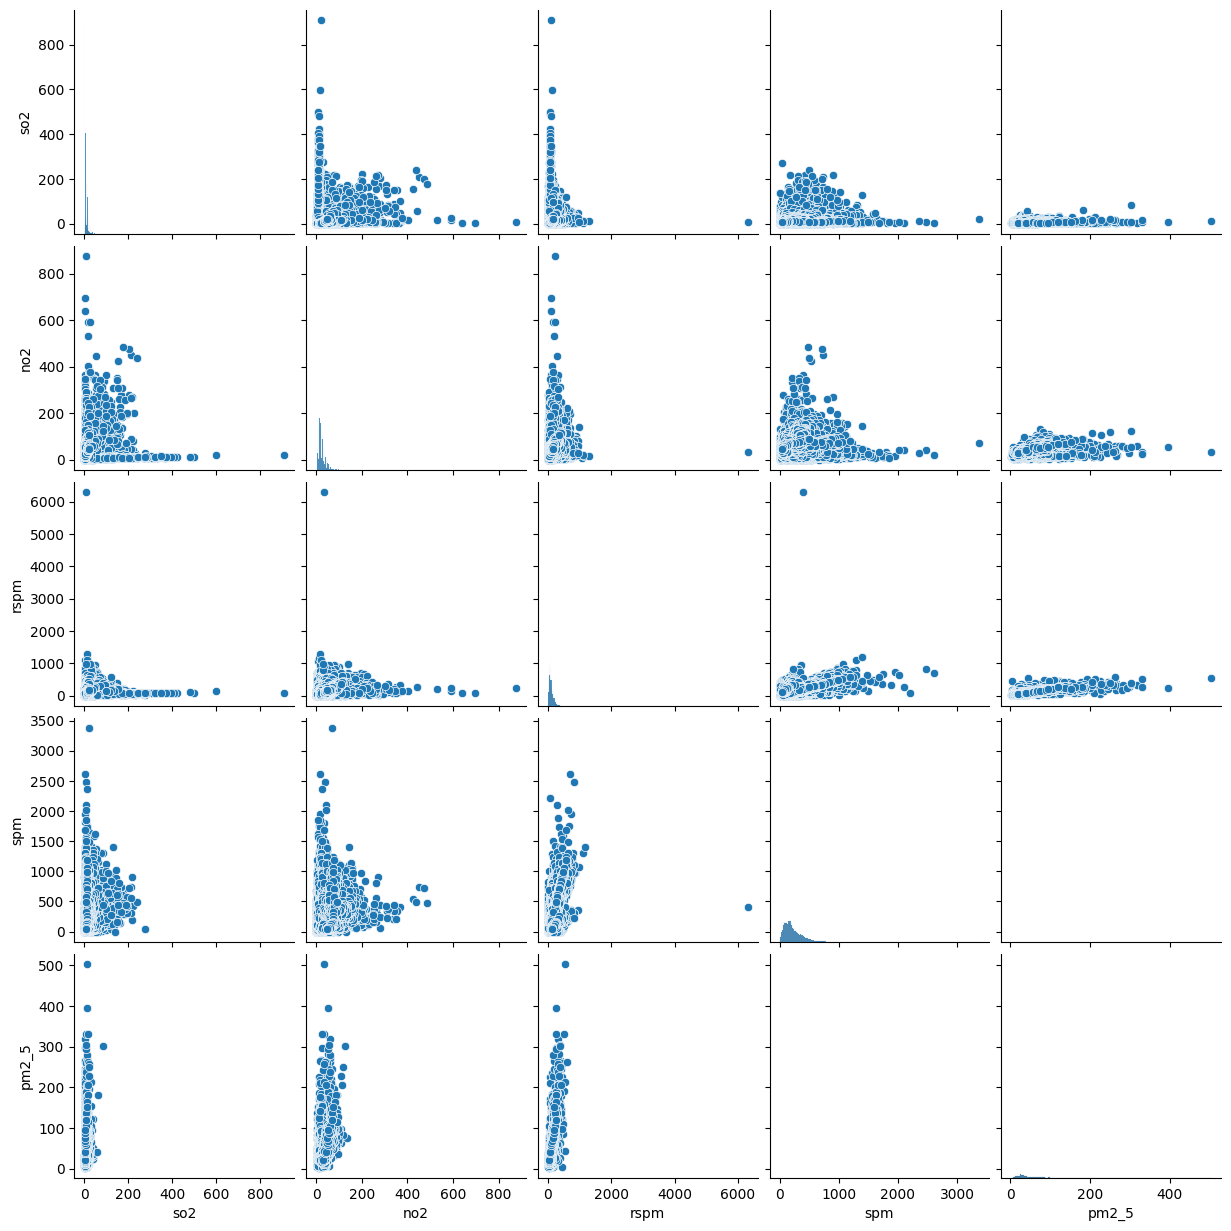

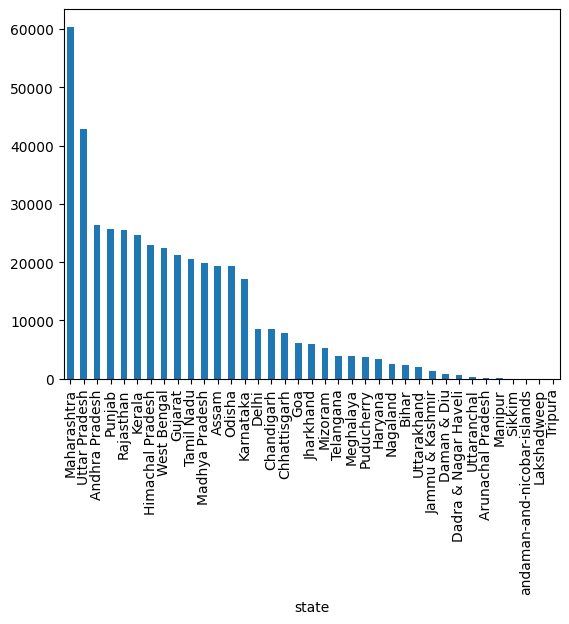

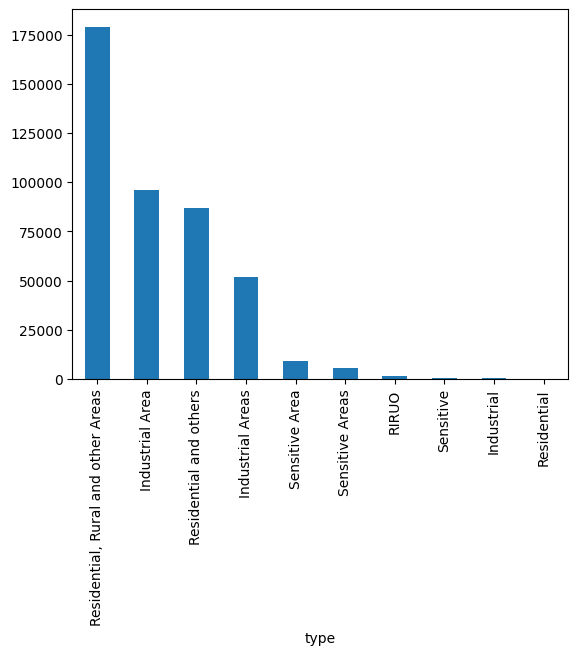

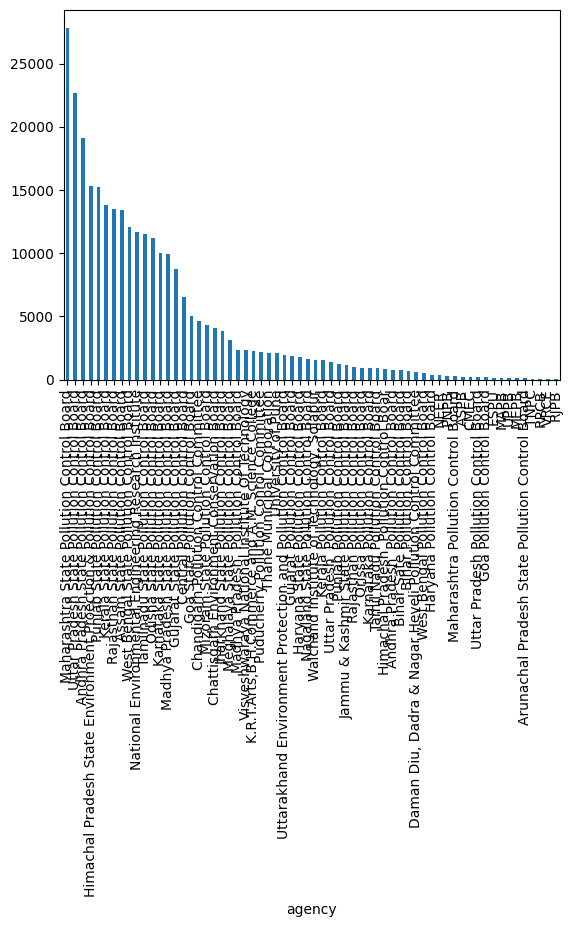

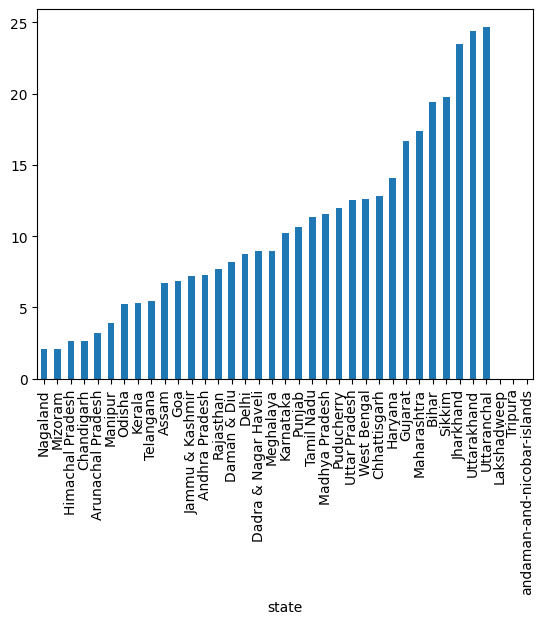

In [ ]:
# Pairplot for pollutant relations
sns.pairplot(df, vars=['so2', 'no2', 'rspm', 'spm', 'pm2_5'])
plt.show()

# Histogram of states
df['state'].value_counts().plot(kind='bar')
plt.show()

# Histogram of area types
df['type'].value_counts().plot(kind='bar')
plt.show()

# Agencies count by state
df['agency'].value_counts().plot(kind='bar')
plt.show()

# Bar plots for average pollutants by state
state_so2 = df.groupby('state')['so2'].mean().sort_values()
state_so2.plot(kind='bar')
plt.show()
# Repeat for 'no2', 'rspm', 'spm', 'pm2_5'


In [ ]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().sum() / df.shape[0]) * 100
missing_data = pd.concat([missing_values, missing_pct], axis=1, keys=['Total', 'Percent'])
print(missing_data)

# Drop columns with high (>60%) missing percentage
df.drop(columns=['pm2_5', 'spm', 'agency', 'stn_code', 'date', 'sampling_date', 'location_monitoring_station'], inplace=True)

# Fill categorical missing with mode
for col in ['location', 'type']:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Fill numeric missing with 0
for col in ['so2', 'no2', 'rspm']:
    df[col].fillna(0, inplace=True)
print(df.isnull().sum())

                              Total    Percent
pm2_5                        426428  97.862497
spm                          237387  54.478797
agency                       149481  34.304933
stn_code                     144077  33.064749
rspm                          40222   9.230692
so2                           34646   7.951035
location_monitoring_station   27491   6.309009
no2                           16233   3.725370
type                           5393   1.237659
date                              7   0.001606
sampling_date                     3   0.000688
location                          3   0.000688
state                             0   0.000000
state       0
location    0
type        0
so2         0
no2         0
rspm        0
dtype: int64


In [ ]:
def calc_si(so2):
    if so2 <= 40:
        return so2 * 0.625
    elif so2 <= 80:
        return 25 + (so2 - 40) * 0.5
    elif so2 <= 380:
        return 45 + (so2 - 80) * 0.178
    elif so2 <= 800:
        return 80 + (so2 - 380) * 0.12
    else:
        return 125

df['si'] = df['so2'].apply(calc_si)

def calc_ni(no2):
    if no2 <= 40:
        return no2 * 0.625
    elif no2 <= 80:
        return 25 + (no2 - 40) * 0.5
    elif no2 <= 380:
        return 45 + (no2 - 80) * 0.178
    elif no2 <= 800:
        return 80 + (no2 - 380) * 0.12
    else:
        return 125

df['ni'] = df['no2'].apply(calc_ni)

def calc_rpi(rspm):
    if rspm <= 60:
        return rspm * 0.5
    elif rspm <= 120:
        return 30 + (rspm - 60) * 0.5
    elif rspm <= 250:
        return 60 + (rspm - 120) * 0.2
    elif rspm <= 350:
        return 90 + (rspm - 250) * 0.2
    else:
        return 125

df['rpi'] = df['rspm'].apply(calc_rpi)


In [ ]:
df['AQI'] = df[['si', 'ni', 'rpi']].max(axis=1)

def get_aqi_range(aqi):
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Moderate'
    elif aqi <= 200:
        return 'Poor'
    elif aqi <= 300:
        return 'Unhealthy'
    elif aqi <= 400:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

df['AQI_Range'] = df['AQI'].apply(get_aqi_range)


In [ ]:
X = df[['si', 'ni', 'rpi']]
y = df['AQI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=70)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Linear Regression RMSE:", mean_squared_error(y_test, y_pred_lr))
print("Linear Regression R²:", r2_score(y_test, y_pred_lr))

# Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=70)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree RMSE:", mean_squared_error(y_test, y_pred_dt))
print("Decision Tree R²:", r2_score(y_test, y_pred_dt))

# Random Forest Regressor
rf = RandomForestRegressor(random_state=70)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest RMSE:", mean_squared_error(y_test, y_pred_rf))
print("Random Forest R²:", r2_score(y_test, y_pred_rf))

Linear Regression RMSE: 21.627608399056683
Linear Regression R²: 0.9642541027359034
Decision Tree RMSE: 0.04464472568552871
Decision Tree R²: 0.999926211638925
Random Forest RMSE: 0.04239218806196075
Random Forest R²: 0.9999299346108316


In [ ]:
X2 = df[['si', 'ni', 'rpi']]
y2 = df['AQI_Range']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.33, random_state=70)

# Logistic Regression
clf_lr = LogisticRegression()
clf_lr.fit(X_train2, y_train2)
print("Logistic Regression Train Accuracy:", clf_lr.score(X_train2, y_train2))
print("Logistic Regression Test Accuracy:", clf_lr.score(X_test2, y_test2))
print("Kappa Score:", cohen_kappa_score(y_test2, clf_lr.predict(X_test2)))

# Decision Tree Classifier
clf_dt = DecisionTreeClassifier(random_state=70)
clf_dt.fit(X_train2, y_train2)
print("Decision Tree Train Accuracy:", clf_dt.score(X_train2, y_train2))
print("Decision Tree Test Accuracy:", clf_dt.score(X_test2, y_test2))
print("Kappa Score:", cohen_kappa_score(y_test2, clf_dt.predict(X_test2)))

# Random Forest Classifier
clf_rf = RandomForestClassifier(random_state=70)
clf_rf.fit(X_train2, y_train2)
print("Random Forest Train Accuracy:", clf_rf.score(X_train2, y_train2))
print("Random Forest Test Accuracy:", clf_rf.score(X_test2, y_test2))
print("Kappa Score:", cohen_kappa_score(y_test2, clf_rf.predict(X_test2)))

# K-Nearest Neighbors Classifier
clf_knn = KNeighborsClassifier()
clf_knn.fit(X_train2, y_train2)
print("KNN Train Accuracy:", clf_knn.score(X_train2, y_train2))
print("KNN Test Accuracy:", clf_knn.score(X_test2, y_test2))
print("Kappa Score:", cohen_kappa_score(y_test2, clf_knn.predict(X_test2)))


Logistic Regression Train Accuracy: 0.9897960931264921
Logistic Regression Test Accuracy: 0.9892485830522619
Kappa Score: 0.9781613279020885
Decision Tree Train Accuracy: 1.0
Decision Tree Test Accuracy: 0.9999860913105463
Kappa Score: 0.9999717773345288
Random Forest Train Accuracy: 1.0
Random Forest Test Accuracy: 0.9999791369658194
Kappa Score: 0.9999576661414362
KNN Train Accuracy: 0.9992430132866582
KNN Test Accuracy: 0.9984074550575472
Kappa Score: 0.9967679763051915


In [ ]:
# Example predictions
sample_features = [[10, 2.8, 17]]
pred_class = clf_lr.predict(sample_features)
print("AQI Range Prediction:", pred_class)


AQI Range Prediction: ['Good']


In [ ]:
# Colab: save your models & metadata for deployment
import joblib, json, os
# replace names if your variables are different, e.g. rf, clf_rf
# (from what I inspected: rf and clf_rf exist)
joblib.dump(rf, 'model_rf.joblib')
joblib.dump(clf_rf, 'model_clf_rf.joblib')

meta = {
    "features": ["si", "ni", "rpi"],
    "model_type": "regression+classification",
    "label_mapping": ["Good","Moderate","Poor","Unhealthy","Very Unhealthy","Hazardous"]
}
with open('metadata.json', 'w') as f:
    json.dump(meta, f)

# Download (Colab): use files.download (works for small files) or copy to Drive
from google.colab import files
files.download('model_rf.joblib')
files.download('model_clf_rf.joblib')
files.download('metadata.json')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>